# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально 

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_ Задача относится к парадигме **supervised learning (обучение с учителем)**: у нас есть размеченные примеры — каждому изображению рукописной цифры (вектор из 784 признаков) сопоставлена известная метка класса (цифра 0–9), и модель обучается отображению «вход → метка». Тип задачи — **многоклассовая классификация** (10 классов, метка дискретна и категориальна). Это не unsupervised (нет скрытой структуры, которую нужно найти без меток) и не reinforcement learning (нет среды, вознаграждения и последовательности действий).

## 2. Загрузка и разведочный анализ данных (EDA)

In [ ]:
# Выбран датасет MNIST (классификация рукописных цифр, 10 классов).
from torchvision import datasets

mnist = datasets.MNIST(root='./data', train=True, download=False)

X_raw = mnist.data.numpy().reshape(len(mnist), -1).astype('float32') / 255.0
y_raw = mnist.targets.numpy()

# Для приемлемого времени обучения на CPU берём стратифицированную подвыборку 12000 примеров
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(y_raw), 12000, replace=False)
X_sub, y_sub = X_raw[idx], y_raw[idx]

df = pd.DataFrame(X_sub, columns=[f'pixel_{i}' for i in range(X_sub.shape[1])])
df['target'] = y_sub
print('Форма датасета:', df.shape)
df.iloc[:5, :6].assign(target=df['target'][:5])  # первые пиксели + метка для наглядности

Форма датасета: (12000, 785)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,target
0,0.0,0.0,0.0,0.0,0.0,0.0,7
1,0.0,0.0,0.0,0.0,0.0,0.0,3
2,0.0,0.0,0.0,0.0,0.0,0.0,8
3,0.0,0.0,0.0,0.0,0.0,0.0,9
4,0.0,0.0,0.0,0.0,0.0,0.0,3


In [3]:
print('Размер выборки:', df.shape)
print('\nЧисло пропусков:', int(df.isna().sum().sum()))
print('\nБаланс классов (target):')
print(df['target'].value_counts().sort_index())
print('\nБазовые статистики (несколько пикселей и target):')
print(df.iloc[:, [100, 200, 300, 400, -1]].describe().T)

Размер выборки: (12000, 785)

Число пропусков: 0

Баланс классов (target):
target
0    1175
1    1322
2    1174
3    1219
4    1176
5    1104
6    1177
7    1299
8    1160
9    1194
Name: count, dtype: int64

Базовые статистики (несколько пикселей и target):
             count      mean       std  min  25%  50%       75%  max
pixel_100  12000.0  0.050543  0.194782  0.0  0.0  0.0  0.000000  1.0
pixel_200  12000.0  0.008152  0.076519  0.0  0.0  0.0  0.000000  1.0
pixel_300  12000.0  0.283426  0.402464  0.0  0.0  0.0  0.654902  1.0
pixel_400  12000.0  0.287314  0.407679  0.0  0.0  0.0  0.695098  1.0
target     12000.0  4.477667  2.883810  0.0  2.0  4.0  7.000000  9.0


**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_ **Пропусков нет** (0 NaN на весь датасет). **Дисбаланса классов практически нет**: в стратифицированной подвыборке 12000 примеров на каждый класс приходится от 1104 (класс 5) до 1322 (класс 1) объектов — различия в пределах ~15%, что несущественно. **Масштабы признаков одинаковы**: все пиксели — интенсивности, нормированные делением на 255 в диапазон [0, 1], поэтому StandardScaler не требуется. Особенность данных — сильная разреженность: краевые пиксели почти всегда равны 0 (например, pixel_200: среднее 0.008, pixel_100: 0.05), информативна лишь центральная часть изображения; медиана большинства пикселей равна 0. Влияние на выбор моделей и предобработки: одинаковый масштаб признаков критичен для k-NN (евклидово расстояние) и MLP (градиентный спуск) — он уже обеспечен нормировкой; отсутствие дисбаланса позволяет использовать accuracy как основную метрику (но в задании С3 проверим, что меняется при его появлении); категориальных признаков нет, кодирование не нужно. Разбиение train/test выполнено стратифицированно (stratify=y), чтобы сохранить распределение классов.

## 3. Предобработка данных

In [4]:
X = df.drop(columns='target').to_numpy()
y = df['target'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Признаки уже нормализованы в [0, 1] (деление интенсивностей на 255),
# поэтому StandardScaler не требуется; категориальных признаков нет.
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Баланс классов в train:', np.bincount(y_train))

X_train: (9000, 784) | X_test: (3000, 784)
Баланс классов в train: [881 992 881 914 882 828 883 974 870 895]


## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [5]:
# Модель 1 (классическая): логистическая регрессия (мультикласс)
model_1 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_1.fit(X_train, y_train)
print('LogisticRegression обучена, train accuracy:', round(model_1.score(X_train, y_train), 4))

LogisticRegression обучена, train accuracy: 0.9711


In [6]:
# Модель 2 (классическая): дерево решений
model_2 = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
print('DecisionTree обучена, train accuracy:', round(model_2.score(X_train, y_train), 4))

DecisionTree обучена, train accuracy: 1.0


In [7]:
# Модель 3 (классическая): k-NN
model_3 = KNeighborsClassifier(n_neighbors=5)
model_3.fit(X_train, y_train)
print('KNN обучена, train accuracy:', round(model_3.score(X_train, y_train), 4))

KNN обучена, train accuracy: 0.9627


In [8]:
# Модель 4 (альтернативная): простой MLP
model_4 = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', solver='adam',
                        max_iter=150, random_state=RANDOM_STATE)
model_4.fit(X_train, y_train)
print('MLP обучена, train accuracy:', round(model_4.score(X_train, y_train), 4))

MLP обучена, train accuracy: 1.0


## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [9]:
models = {
    'LogisticRegression': model_1,
    'DecisionTree': model_2,
    'KNN': model_3,
    'MLP': model_4,
}

rows = []
for name, m in models.items():
    pred = m.predict(X_test)
    rows.append({
        'model': name,
        'metric_1_accuracy': accuracy_score(y_test, pred),
        'metric_2_f1_macro': f1_score(y_test, pred, average='macro'),
        'recall_macro': recall_score(y_test, pred, average='macro'),
    })

results = pd.DataFrame(rows).set_index('model').sort_values('metric_1_accuracy', ascending=False)
results.round(4)

,metric_1_accuracy,metric_2_f1_macro,recall_macro
model,,,
MLP,0.9527,0.9522,0.9521
KNN,0.9503,0.9501,0.9495
LogisticRegression,0.9020,0.9003,0.9004
DecisionTree,0.7987,0.7955,0.7955


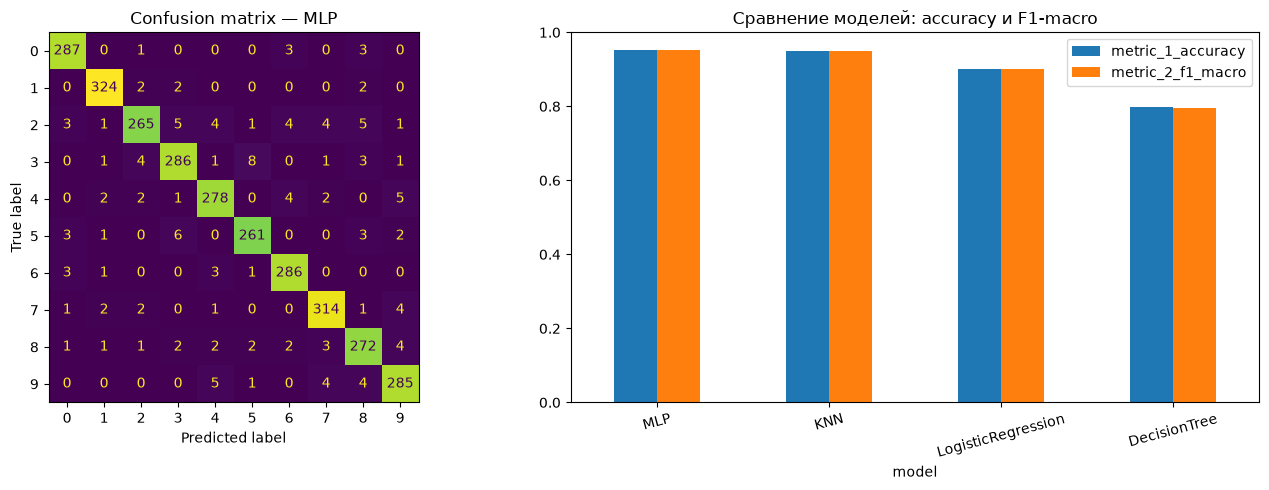

In [10]:
# Визуализация 1: confusion matrix лучшей модели; Визуализация 2: сравнение метрик
best_name = results.index[0]
pred_best = models[best_name].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_best, ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion matrix — {best_name}')
results[['metric_1_accuracy', 'metric_2_f1_macro']].plot(kind='bar', ax=axes[1], rot=15)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Сравнение моделей: accuracy и F1-macro')
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_ Выбраны **accuracy** и **F1-macro** (плюс recall-macro как диагностика). Accuracy интерпретируема и адекватна при сбалансированных классах; F1-macro усредняет F1 по всем 10 классам без учёта их весов и поэтому чувствительна к качеству на каждом отдельном классе. **Accuracy вводит в заблуждение при дисбалансе классов**: если одного класса 95% примеров, тривиальная модель «всегда предсказывать большинство» получит accuracy ≈ 0.95, но полностью провалится на меньшинственном классе. В нашем эксперименте (задание С3) это проявилось: после искусственного undersampling класса 1 (992 → 49 примеров) MLP сохранил высокую общую accuracy (0.946 против 0.953 на сбалансированных данных), но его recall на классе 1 упал до 0.897, тогда как у KNN — 0.961. Общая accuracy «не видит» деградацию на редком классе, а per-class метрики (recall/F1 для класса 1) — видят.

## 6. Анализ ошибок

Лучшая модель: MLP, ошибок на тесте: 142 из 3000

Топ-5 путаемых пар (истинный класс -> предсказанный):
  3 -> 5: 8 ошибок
  5 -> 3: 6 ошибок
  2 -> 8: 5 ошибок
  2 -> 3: 5 ошибок
  4 -> 9: 5 ошибок


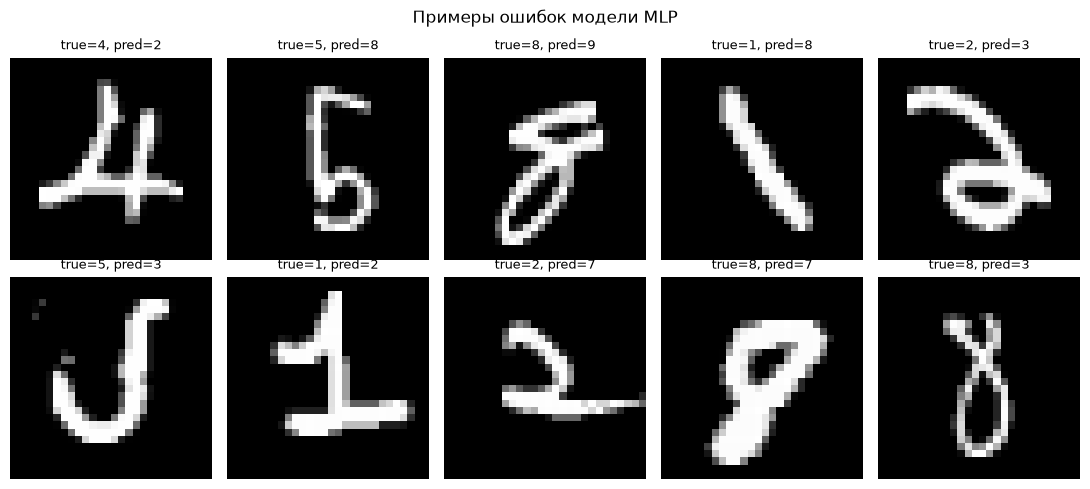

In [11]:
# Анализ ошибок лучшей модели: какие классы путаются чаще всего
cm = confusion_matrix(y_test, pred_best)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-cm_off.ravel()), cm_off.shape))[0]

print(f'Лучшая модель: {best_name}, ошибок на тесте: {(pred_best != y_test).sum()} из {len(y_test)}')
print('\nТоп-5 путаемых пар (истинный класс -> предсказанный):')
for i, j in pairs[:5]:
    if cm_off[i, j] == 0:
        break
    print(f'  {i} -> {j}: {cm_off[i, j]} ошибок')

# Примеры неверно классифицированных объектов
mis_idx = np.where(pred_best != y_test)[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, k in zip(axes.ravel(), mis_idx):
    ax.imshow(X_test[k].reshape(28, 28), cmap='gray')
    ax.set_title(f'true={y_test[k]}, pred={pred_best[k]}', fontsize=9)
    ax.axis('off')
plt.suptitle(f'Примеры ошибок модели {best_name}')
plt.tight_layout()
plt.show()

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_ **Лучший результат — у MLP**: test accuracy 0.9527, F1-macro 0.9522. Далее KNN (0.9503 / 0.9501), логистическая регрессия (0.9020 / 0.9003) и дерево решений (0.7987 / 0.7955). Это согласуется с ожиданиями: изображения цифр — данные высокой размерности (784 признака) со сложной нелинейной границей решения. Линейная модель (LogReg) закономерно упирается в предел ~0.90 — она не может разделить классы, различающиеся формой (пары 3/5, 4/9 — именно они лидируют в анализе ошибок). Дерево решений без ограничения глубины **сильно переобучилось**: train accuracy = 1.0 при test = 0.799 — самый большой generalization gap (~0.20), что типично для жадных деревьев на данных большого размера с шумом. KNN близок к MLP, так как MNIST — «лёгкая» задача для метрических методов (соседние изображения цифр действительно похожи). Анализ ошибок MLP (142 ошибки из 3000): топ путаемых пар 3→5 (8), 5→3 (6), 2→8 (5), 2→3 (5), 4→9 (5) — это систематическая ошибка на визуально схожих классах, а не случайный шум. **В качестве baseline я бы выбрал логистическую регрессию** — она обучается быстрее всех, стабильна (std по фолдам CV всего 0.005) и задаёт честную нижнюю планку 0.90; а **рабочей моделью — MLP**, дающий максимальное качество (0.953). Подтверждение стабильности из С4 (3-fold CV, подвыборка 6000): MLP 0.9320 ± 0.0079, KNN 0.9200 ± 0.0118, LogReg 0.8857 ± 0.0049, DT 0.7628 ± 0.0131 — порядок моделей сохраняется, разброс по фолдам небольшой.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже 

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


In [12]:
# ВЫПОЛНЕНЫ ЗАДАНИЯ С3 И С4 (см. ячейки ниже)

In [13]:
# С3. Устойчивость вывода о «лучшей» модели к выбору метрики (искусственный дисбаланс)
# Оставляем только 5% примеров класса "1" в обучающей выборке и переобучаем все модели.
rng2 = np.random.RandomState(RANDOM_STATE)
mask = y_train != 1
idx_1 = np.where(y_train == 1)[0]
idx_1_keep = rng2.choice(idx_1, size=max(1, int(0.05 * len(idx_1))), replace=False)
mask[idx_1_keep] = True
X_train_imb, y_train_imb = X_train[mask], y_train[mask]
print('Примеров класса 1 в train: было', (y_train == 1).sum(), '-> стало', (y_train_imb == 1).sum())

rows_imb = []
for name, m_new in [
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('DecisionTree', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(128,), max_iter=150, random_state=RANDOM_STATE)),
]:
    m_new.fit(X_train_imb, y_train_imb)
    pred = m_new.predict(X_test)
    rows_imb.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'recall_class_1': recall_score(y_test, pred, labels=[1], average='macro'),
    })

results_imb = pd.DataFrame(rows_imb).set_index('model')
results_imb['rank_by_accuracy'] = results_imb['accuracy'].rank(ascending=False).astype(int)
results_imb['rank_by_f1'] = results_imb['f1_macro'].rank(ascending=False).astype(int)
print('\nРанжирование моделей на несбалансированных данных:')
results_imb.round(4)

Примеров класса 1 в train: было 992 -> стало 49



Ранжирование моделей на несбалансированных данных:


,accuracy,f1_macro,recall_class_1,rank_by_accuracy,rank_by_f1
model,,,,,
LogisticRegression,0.8877,0.8870,0.8091,3,3
DecisionTree,0.7653,0.7651,0.5576,4,4
KNN,0.9527,0.9523,0.9606,1,1
MLP,0.9460,0.9460,0.8970,2,2


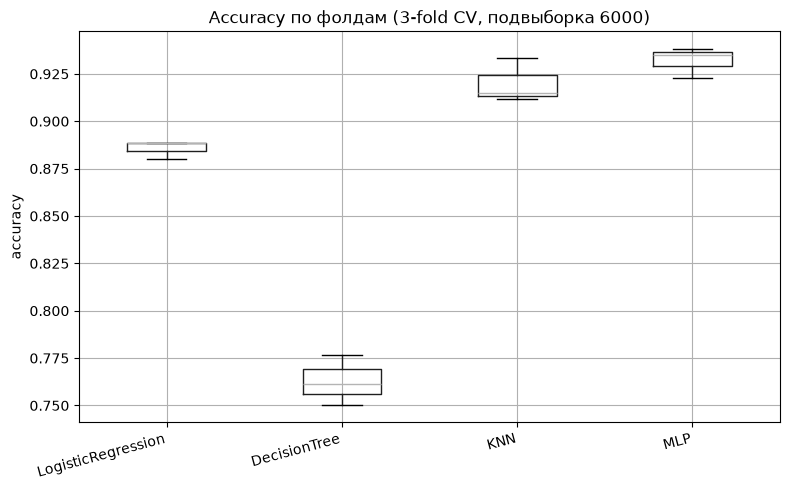

Среднее и ст. отклонение accuracy по фолдам:


,mean,std
LogisticRegression,0.8857,0.0049
DecisionTree,0.7628,0.0131
KNN,0.9200,0.0118
MLP,0.9320,0.0079


In [14]:
# С4. Кросс-валидация и стабильность качества (3-fold CV на подвыборке 6000 для скорости)
cv_idx = rng2.choice(len(X_train), 6000, replace=False)
X_cv, y_cv = X_train[cv_idx], y_train[cv_idx]

cv_models = {
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=RANDOM_STATE),
}

cv_scores = {name: cross_val_score(m, X_cv, y_cv, cv=3, scoring='accuracy')
             for name, m in cv_models.items()}
cv_df = pd.DataFrame(cv_scores)

cv_df.boxplot(figsize=(8, 5))
plt.title('Accuracy по фолдам (3-fold CV, подвыборка 6000)')
plt.ylabel('accuracy')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('Среднее и ст. отклонение accuracy по фолдам:')
cv_df.agg(['mean', 'std']).T.round(4)

**Выводы по С3 (дисбаланс) и С4 (кросс-валидация).**

**С3.** После undersampling класса 1 (992 → 49 примеров) ранжирование моделей по accuracy изменилось: лидером стал **KNN (0.9527)**, а MLP опустился на второе место (0.9460), тогда как на сбалансированных данных MLP был первым (0.9527 против 0.9503 у KNN). Ранжирование по accuracy и по F1-macro внутри эксперимента совпало (KNN > MLP > LogReg > DT), но главная находка другая: общая accuracy у всех моделей почти не изменилась, тогда как **recall на меньшинственном классе 1 резко различается**: KNN 0.961, MLP 0.897, LogReg 0.809, DT 0.558. Модель, обученная на 49 примерах класса 1, начинает систематически «жертвовать» этим классом, и по общей accuracy это практически незаметно. Вывод: **выбор метрики критичен при дисбалансе** — нужно смотреть per-class recall/F1, а не только агрегированную accuracy; иначе можно внедрить модель, которая хорошо выглядит в отчёте и проваливается на важном редком классе (в антифроде/медицине цена такой ошибки максимальна). Интересно, что KNN оказался устойчивее MLP к дисбалансу: метрический метод «помнит» все 49 примеров класса 1 буквально, а MLP сглаживает редкий класс при оптимизации среднего лосса.

**С4.** По 3-fold кросс-валидации (подвыборка 6000) средние accuracy: MLP 0.9320 ± 0.0079, KNN 0.9200 ± 0.0118, LogReg 0.8857 ± 0.0049, DT 0.7628 ± 0.0131. Boxplot показывает, что разброс по фолдам у всех моделей мал (< 0.015), т.е. результаты **стабильны** и вывод о преимуществе MLP/KNN над линейной моделью и деревом не является артефактом одного разбиения. Наименее стабильны DecisionTree и KNN (std ≈ 0.012–0.013): дерево чувствительно к составу выборки из-за жадного построения, KNN — из-за локальности метрики. Значения CV чуть ниже single-split оценок (0.932 против 0.953 у MLP), так как модели в CV обучаются на 4000–6000 примеров вместо 9000: качество продолжает расти с объёмом данных, что подтверждает отсутствие насыщения у MLP/KNN и полезность наращивания обучающей выборки.